Data Preprocessing

In [1]:
import numpy as ali
import pandas as ahmad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=ahmad.read_csv('earthquake_alert_balanced_dataset.csv')
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [3]:
df.shape

(1300, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
duplicates_mask=df.duplicated()
duplicates_mask.sum()

np.int64(44)

In [7]:
df = df.drop_duplicates()


In [8]:
duplicates_mask=df.duplicated()
duplicates_mask.sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
 5   alert      1256 non-null   object 
dtypes: float64(5), object(1)
memory usage: 68.7+ KB


In [10]:
for i in df.columns:
    if(df[i].dtype == 'float64'):
        print(i , df[i].value_counts())

magnitude magnitude
6.50    98
6.60    77
6.90    70
6.70    53
6.80    48
        ..
8.17     1
8.09     1
7.87     1
8.02     1
8.33     1
Name: count, Length: 167, dtype: int64
depth depth
10.0     109
9.0       70
12.0      69
11.0      59
13.0      51
        ... 
595.0      1
414.0      1
169.0      1
553.0      1
129.0      1
Name: count, Length: 173, dtype: int64
cdi cdi
8.0    514
9.0    233
7.0    184
6.0    101
5.0     75
0.0     59
4.0     34
3.0     30
1.0     14
2.0     12
Name: count, dtype: int64
mmi mmi
8.0    443
7.0    426
6.0    164
5.0     67
4.0     64
9.0     53
3.0     34
2.0      4
1.0      1
Name: count, dtype: int64
sig sig
 93.0     23
-118.0    19
 26.0     18
-115.0    18
-98.0     18
          ..
 20.0      1
 6.0       1
-107.0     1
-83.0      1
 37.0      1
Name: count, Length: 238, dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [12]:
for i in df.columns: 
    if(df[i].dtype == 'object'): 
        df[i] = le.fit_transform(df[i])
        print(i , df[i].value_counts())

alert alert
0    322
3    318
1    316
2    300
Name: count, dtype: int64


Correlation

In [13]:
correlation=df.corr()
correlation

,magnitude,depth,cdi,mmi,sig,alert
magnitude,1.000000,-0.017037,0.326727,0.306400,0.239390,0.229520
depth,-0.017037,1.000000,-0.372096,-0.567678,-0.100912,-0.252869
cdi,0.326727,-0.372096,1.000000,0.676274,0.376892,0.446708
mmi,0.306400,-0.567678,0.676274,1.000000,0.325530,0.451719
sig,0.239390,-0.100912,0.376892,0.325530,1.000000,0.124579
alert,0.229520,-0.252869,0.446708,0.451719,0.124579,1.000000


<Axes: >

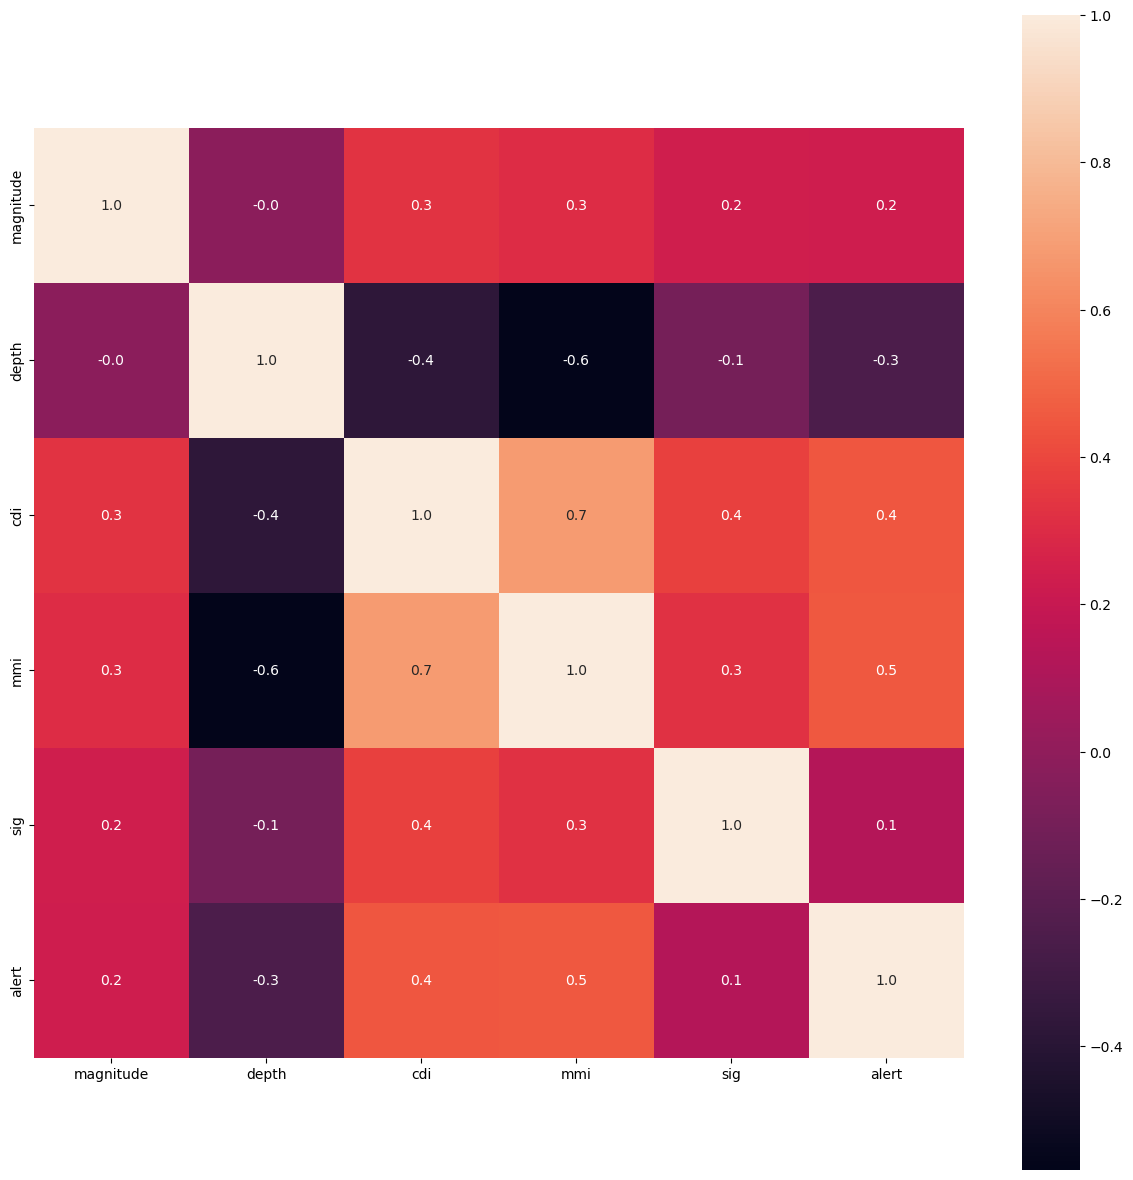

In [14]:
plt.figure(figsize=(15,15))
sns.heatmap(correlation, square=True, fmt='.1f', annot=True)

In [ ]:
DATA SPLITING

In [15]:
X =df.drop('magnitude', axis=1)
Y = df['magnitude']

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   depth   1256 non-null   float64
 1   cdi     1256 non-null   float64
 2   mmi     1256 non-null   float64
 3   sig     1256 non-null   float64
 4   alert   1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [18]:
Y.info()

<class 'pandas.core.series.Series'>
Index: 1256 entries, 0 to 1299
Series name: magnitude
Non-Null Count  Dtype  
--------------  -----  
1256 non-null   float64
dtypes: float64(1)
memory usage: 19.6 KB


In [19]:
from sklearn.model_selection  import train_test_split
X_TRAIN , X_TEST , Y_TRAIN, Y_TEST = train_test_split(X,Y, test_size = 
0.25, random_state=25)
print("Size of Train X =  " , len(X_TRAIN))
print("Size of Train Y =  " , len(Y_TRAIN))
print("Size of Test X =  " , len(X_TEST))
print("Size of Test Y =  " , len(Y_TEST))

Size of Train X =   942
Size of Train Y =   942
Size of Test X =   314
Size of Test Y =   314


LINEAR REGRESSION

In [20]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_TRAIN, Y_TRAIN) 

LinearRegression()

Prediction on Train Data

In [21]:
 # accuracy for prediction on training data
training_data_prediction = model.predict(X_TRAIN)
print(training_data_prediction)

[7.14100542 7.09552787 7.13597543 7.11142202 6.80839644 6.73450192
 7.04480706 6.63919056 7.21365212 7.17465508 7.18073095 7.15771287
 7.19513274 7.22861539 7.1847511  7.27799943 6.8022114  7.26725937
 7.23074183 6.45447157 7.19564362 7.07569219 7.15809381 7.09735669
 6.66698249 7.09879163 7.16912675 7.2382435  7.17854874 7.19510319
 7.10308246 6.79300466 7.04081808 7.04216252 7.19466485 7.08137578
 7.22507118 7.16820893 6.50339244 7.07878705 7.08986084 6.84248836
 7.09685879 6.96697481 6.93206595 6.98397494 7.10350821 7.15229292
 7.03162176 7.12008992 7.09101827 7.01264611 6.95722311 6.89014392
 7.18073095 7.18324292 7.18291316 7.02171538 7.13163921 7.20527314
 7.15552911 7.11301992 7.22590762 7.20826784 7.27080304 6.95538747
 7.00904765 7.11882553 7.09822038 7.03116175 7.25977251 7.06653155
 6.99718166 6.63234795 7.14955527 7.18228096 7.00558658 7.17602225
 7.0372878  7.34429892 7.13805539 7.19648006 7.10526467 7.15428153
 7.24937176 7.1441664  7.10051055 6.95567566 6.64376414 7.1192

In [24]:
# R squared error
score_1 = metrics.r2_score(Y_TRAIN, training_data_prediction)
print(score_1)

0.1668041365802332


In [25]:
# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_TRAIN, training_data_prediction)
print(score_2)

0.3021871359524427


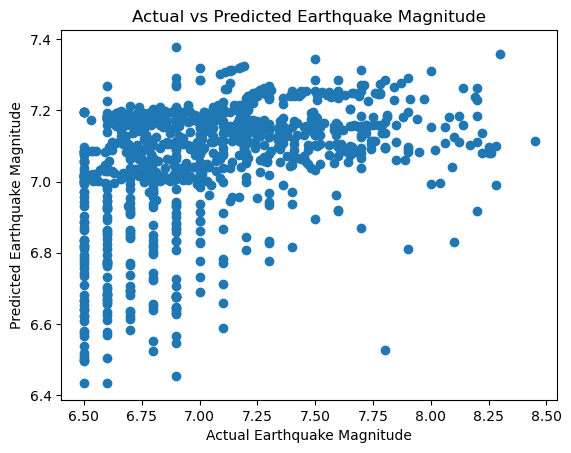

In [28]:
plt.scatter(Y_TRAIN, training_data_prediction)
plt.xlabel("Actual Earthquake Magnitude")
plt.ylabel("Predicted Earthquake Magnitude")
plt.title("Actual vs Predicted Earthquake Magnitude")
plt.show()


Prediction on Test Data

In [29]:
y_pred =model.predict(X_TEST)
y_pred
print(y_pred)

[7.109872   6.72242247 7.07762574 7.0468116  7.15364933 6.99216293
 7.1575644  7.13326476 6.95166523 7.0432152  7.13601727 7.18192605
 7.15745709 7.05960548 6.50889936 7.22627175 7.04532253 7.06741213
 7.1765935  7.16808704 7.22268952 7.1453504  6.99295815 7.19959995
 6.61947064 7.05178911 7.17261461 7.05867869 7.09388515 6.99316381
 7.06677534 6.98567933 7.28095178 7.18192605 6.96693018 6.89289474
 7.13756729 7.16170414 7.05133654 7.0842382  7.08170453 7.19880402
 7.03684074 7.0671028  7.24617971 7.04350697 7.2239044  7.18255824
 7.26570935 7.13339864 7.24352574 7.18192605 7.08297071 7.02539184
 6.6907362  6.43130502 7.18100823 7.15638753 7.10637797 7.31718558
 7.04356177 6.60819746 6.81277944 6.63177671 7.15778907 6.99999606
 7.18353471 7.14916531 7.09389647 7.11370284 6.91873889 7.09840322
 7.08821725 7.16878018 6.8304877  7.2610369  7.00442757 7.0582748
 7.17135927 7.19100651 6.99977138 7.10661758 6.73443418 7.01745989
 7.13286176 6.68350325 6.97919815 7.23841699 7.21643995 6.58070

In [30]:
# R squared Score
score_1=metrics.r2_score(Y_TEST, y_pred)
# Mean Absolute Error
score_2=metrics.mean_absolute_error(Y_TEST, y_pred)
print("R squared Score : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared Score :  0.16706424679572573
Mean Absolute Error :  0.30656428401158675


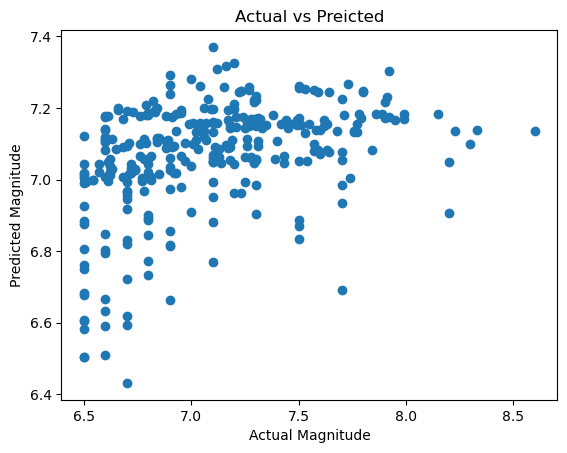

In [31]:
plt.scatter(Y_TEST, y_pred)
plt.xlabel( "Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Preicted")
plt.show()

SVM REGRESSION

In [32]:
from sklearn.svm import SVR
svr=SVR(kernel= 'linear') 
svr.fit(X_TRAIN, Y_TRAIN) 
SVR(kernel='linear')

SVR(kernel='linear')

Prediction on Train Data

In [33]:
# accuracy for prediction on training data
training_data_prediction =svr.predict(X_TRAIN)
print(training_data_prediction)

[7.05996018 7.00649066 7.07744403 7.05700828 6.71409974 6.69487899
 6.97548481 6.56293521 7.15033863 7.12538516 7.12793031 7.07963339
 7.13946937 7.1820342  7.13259646 7.21384593 6.77849805 7.25302862
 7.16075066 6.5066522  7.11344254 6.98502688 7.0954892  7.02614911
 6.66732764 7.00610986 7.11204814 7.1484326  7.12528682 7.17353009
 7.05352721 6.73196507 6.95938895 6.97173969 7.11111623 6.97794057
 7.16049708 7.11139257 6.52575337 7.01058225 6.9818316  6.76156307
 7.04986059 6.87826307 6.89348486 6.91897651 7.05244047 7.10065705
 6.90043095 7.06591152 7.04971468 6.96098412 6.87669714 6.84286835
 7.12793031 7.12392559 7.1305738  6.96931825 7.07064855 7.18009677
 7.07484071 7.04216207 7.17590684 7.148309   7.19837859 6.875386
 6.92510437 7.0639236  7.00678664 6.98203929 7.19675073 6.98501405
 6.93389525 6.59985572 7.06838264 7.12957984 6.83622996 7.12202248
 6.96880021 7.2820205  7.05673428 7.12885229 7.05617071 7.08083336
 7.18118574 7.06492999 6.98182323 6.82605136 6.63298198 7.065503

In [34]:
# R squared error
score_1 =metrics.r2_score(Y_TRAIN, training_data_prediction)
# Mean Absolute Error
score_2 =metrics.mean_absolute_error(Y_TRAIN, training_data_prediction)
print("R squared : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared :  0.13970514113642507
Mean Absolute Error :  0.29743122706301


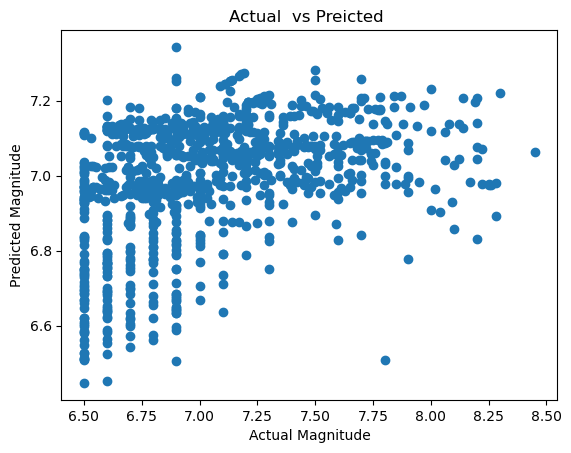

In [35]:
plt.scatter(Y_TRAIN, training_data_prediction)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual  vs Preicted ")
plt.show()

Prediction on Test Data

In [36]:
y_pred = svr.predict(X_TEST)
y_pred
print(y_pred)

[7.05535874 6.68523508 7.03970494 6.95085979 7.0798394  6.92767046
 7.08914464 7.10171971 6.87752586 6.98085661 7.0704227  7.13701039
 7.11355405 6.95835241 6.52968681 7.18378208 6.95088099 6.99411397
 7.1213457  7.10805109 7.17956221 7.01506935 6.8494483  7.13940576
 6.63784245 6.94844867 7.13333754 6.98211698 7.03827941 6.92994061
 6.991697   6.89485605 7.2302431  7.13701039 6.83630281 6.80263782
 7.07207223 7.09644075 6.95684151 6.99058865 7.04533032 7.14209166
 6.97352997 6.98433727 7.20069224 6.98409042 7.17541486 7.13800435
 7.25137909 7.06445757 7.15437516 7.13701039 6.98430236 6.94968424
 6.5915737  6.46786653 7.13635482 7.07597473 7.01803739 7.26160338
 6.98218896 6.58100003 6.75678264 6.60053249 7.08713551 6.93753271
 7.13961916 7.07192244 7.01959531 7.11484573 6.87737384 7.01179885
 7.00083846 7.11071579 6.77370147 7.19873865 6.94806263 6.95470841
 7.12441376 7.10115405 6.93954183 7.0852649  6.70412033 6.96225286
 7.0796578  6.67912795 6.98186372 7.23624567 7.16682881 6.5879

In [37]:
# R squared Score
score_1 = metrics.r2_score(Y_TEST, y_pred)
 # Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_TEST, y_pred)
print("R squared Score : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared Score :  0.12350898289817747
Mean Absolute Error :  0.3061586728651453


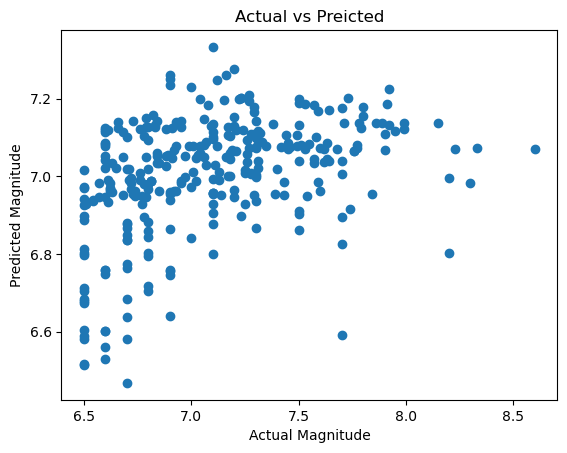

In [38]:
plt.scatter(Y_TEST, y_pred)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Preicted")
plt.show()

REGRESSION DECISION TREE

In [40]:
# import the regressor
from sklearn.tree import DecisionTreeRegressor
# create a regressor object
regressor = DecisionTreeRegressor(random_state =25)
# fit the regressor with X and Y data 25)
regressor.fit(X_TRAIN, Y_TRAIN)
DecisionTreeRegressor(random_state=25)

DecisionTreeRegressor(random_state=25)

Prediction on Train Data

In [41]:
# accuracy for prediction on training data
training_data_prediction = regressor.predict(X_TRAIN)
print (training_data_prediction)

[7.14       7.19       6.87       6.86       6.9        6.5
 7.39       6.5        7.08       7.065      6.745      6.772
 6.88       7.84       6.98       7.87       6.8        6.9
 7.3        6.9        6.5        6.5        7.79       7.6
 6.5        7.65       7.41       7.57       6.94       7.49
 7.51       6.6        7.04       6.97       6.5        8.22
 6.6        6.95       6.6        6.5        6.9        6.7
 7.01       7.3        6.6        7.         6.95       7.69
 6.8        6.76       7.19       6.51       7.14       7.
 6.745      6.68       6.61       6.52       7.5        6.9
 7.1        7.17       7.2        6.74       7.7        7.17
 6.88       7.01       6.77       7.5        7.12       7.2
 6.59       6.7        7.05       6.6475     6.5        6.83
 6.9        7.5        7.38       7.10166667 7.61       7.52
 7.665      7.19       8.28       6.8        6.9        7.41
 7.3        7.0725     7.0725     6.5        6.94       6.7
 6.93       7.         7.21     

In [43]:
 #R squared error
score_1 =metrics.r2_score(Y_TRAIN, training_data_prediction)
 # Mean Absolute Error
score_2 =metrics.mean_absolute_error(Y_TRAIN, training_data_prediction)
print("R squared : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared :  0.9976551013972944
Mean Absolute Error :  0.00376185421089885


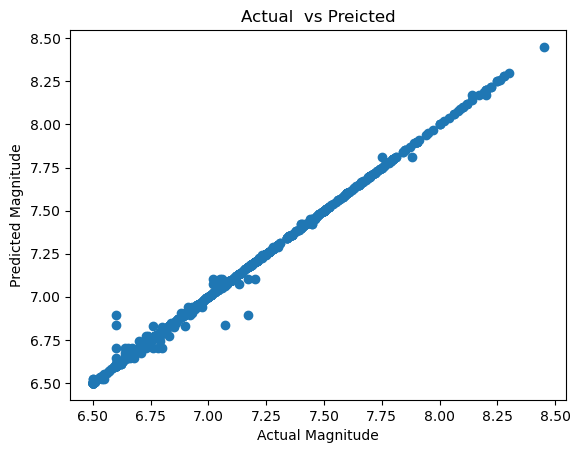

In [44]:
plt.scatter(Y_TRAIN, training_data_prediction)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual  vs Preicted")
plt.show()

Prediction on Test Data

In [45]:
y_pred = regressor.predict(X_TEST)
y_pred
print(y_pred)

[6.9        7.9        7.695      7.52       7.48       6.5
 7.65       7.18       6.9        6.77       8.45       7.81333333
 7.11       6.6        6.6        7.27       7.52       7.09
 6.78       6.91       7.5        7.24       7.6        6.66
 6.8        7.58       7.         6.61       7.24       6.5
 6.8        6.7        7.13       7.81333333 6.7        6.6
 7.3        7.         7.1        6.96       7.66       6.88
 8.1        7.42       6.8        6.6        7.73       7.81333333
 6.9        7.68       7.69       7.81333333 7.56       6.73
 6.7        6.7        8.08       7.36       7.41       7.17
 6.5        6.6        6.9        6.7        7.35       6.56
 6.92       7.1        7.05       6.62       7.1        6.69
 6.7        7.41       7.3        7.12       6.79       7.65
 7.1        6.69       6.5        7.05       6.9        6.83
 7.79       6.5        6.9        6.9        7.17       6.5
 6.66       6.5        6.75       7.         6.745      6.87
 7.19       6.8 

In [46]:
# R squared Score
score_1 = metrics.r2_score(Y_TEST, y_pred)
# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_TEST, y_pred)
print("R squared Score : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared Score :  0.5541152359388396
Mean Absolute Error :  0.16198911889596607


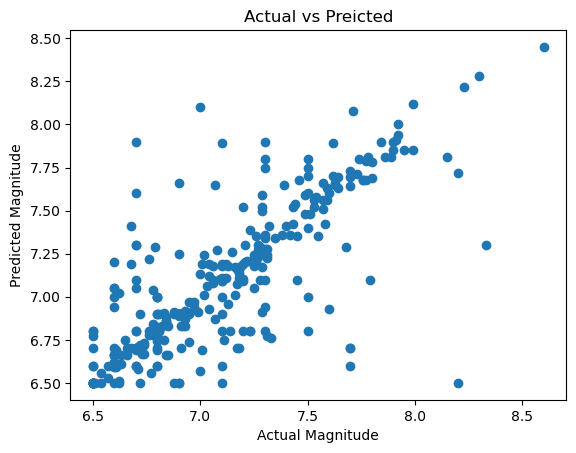

In [47]:
plt.scatter(Y_TEST, y_pred)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Preicted")
plt.show()

RANDOM FOREST

In [48]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=5, random_state=25)

In [49]:
# fit the regressor with X and Y data 
regressor.fit(X_TRAIN, Y_TRAIN)

RandomForestRegressor(n_estimators=5, random_state=25)

Prediction on Training Data

In [50]:
# accuracy for prediction on training data
training_data_prediction = regressor.predict(X_TRAIN)
print(training_data_prediction)

[7.184      7.098      6.868      6.876      6.82       6.5
 7.25       6.52       7.08       7.06146667 6.709      6.76931667
 6.922      7.818      6.95       7.866      6.78       6.84
 7.38       6.9        6.5        6.562      7.79       7.522
 6.5        7.62       7.356      7.506      6.92       7.316
 7.55666667 6.66       6.958      6.93       6.694      8.25
 6.6        6.95       6.6        6.56       7.144      6.92
 7.016      7.3        6.772      6.904      6.86       7.294
 6.8        6.762      6.896      6.514      7.126      7.
 6.709      6.666      6.623      6.55933333 7.5        6.92
 6.9096     7.178      7.2        6.852      7.806      7.186
 7.054      6.89       6.818      7.864      7.198      7.12
 6.59       6.72       7.05       6.64066667 6.5        6.882
 7.098      7.59       7.42       7.107      7.578      7.508
 7.6655     7.214      8.144      6.8        6.9        7.326
 7.32       7.08766667 7.08766667 6.5        6.93866667 6.858
 6.94533333 6

In [51]:
# R squared error
score_1 = metrics.r2_score(Y_TRAIN, training_data_prediction)
# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_TRAIN, training_data_prediction)
print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9263896992794391
Mean Absolute Error :  0.06305577208236451


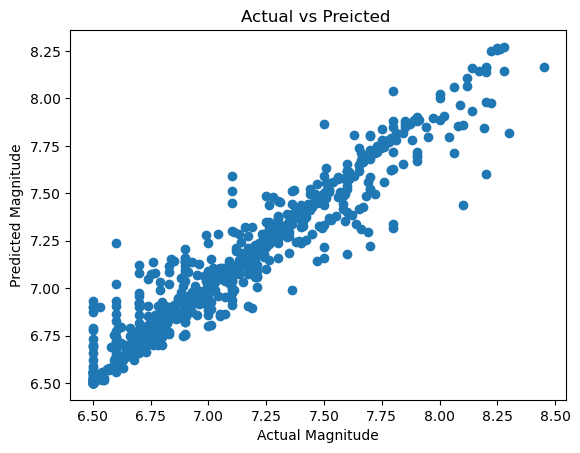

In [52]:
plt.scatter(Y_TRAIN, training_data_prediction)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Preicted ")
plt.show()

Prediction on Test Data

In [53]:
y_pred = regressor.predict(X_TEST)
y_pred

array([6.892     , 6.692     , 7.60566667, 7.52      , 7.48      ,
       6.918     , 7.498     , 7.088     , 7.326     , 6.718     ,
       8.262     , 7.78166667, 7.294     , 6.7       , 6.6       ,
       7.202     , 7.22      , 7.09      , 6.78      , 7.084     ,
       7.364     , 7.166     , 7.28      , 6.678     , 6.9       ,
       7.418     , 7.01      , 6.584     , 7.362     , 6.5       ,
       6.78      , 6.76      , 7.284     , 7.78166667, 6.92      ,
       6.92      , 8.032     , 7.038     , 7.2       , 7.114     ,
       7.58666667, 6.922     , 7.298     , 7.42577778, 7.436     ,
       6.954     , 7.706     , 7.87966667, 6.863     , 7.208     ,
       7.524     , 7.78166667, 7.48      , 6.664     , 6.78      ,
       6.7       , 7.835     , 7.488     , 7.384     , 7.158     ,
       6.684     , 6.62      , 7.052     , 6.62      , 7.188     ,
       6.572     , 6.93      , 6.7876    , 7.17      , 6.656     ,
       7.02      , 6.978     , 6.724     , 7.038     , 6.94   

In [54]:
# R squared Score
score_1 = metrics.r2_score(Y_TEST, y_pred)
# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_TEST, y_pred)
print("R squared Score : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared Score :  0.6430793373476379
Mean Absolute Error :  0.1630719593569912


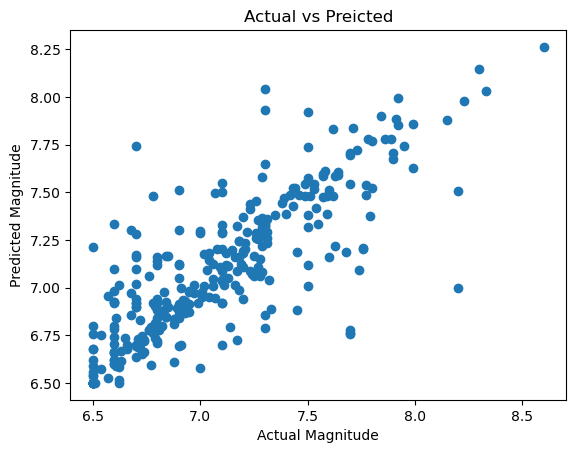

In [55]:
plt.scatter(Y_TEST, y_pred)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Preicted")
plt.show()

In [56]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [57]:
# Assuming regressor is your trained Random Forest model
# Pick one tree from the forest, e.g., the first tree (index 0)
tree_to_plot = regressor.estimators_[0]

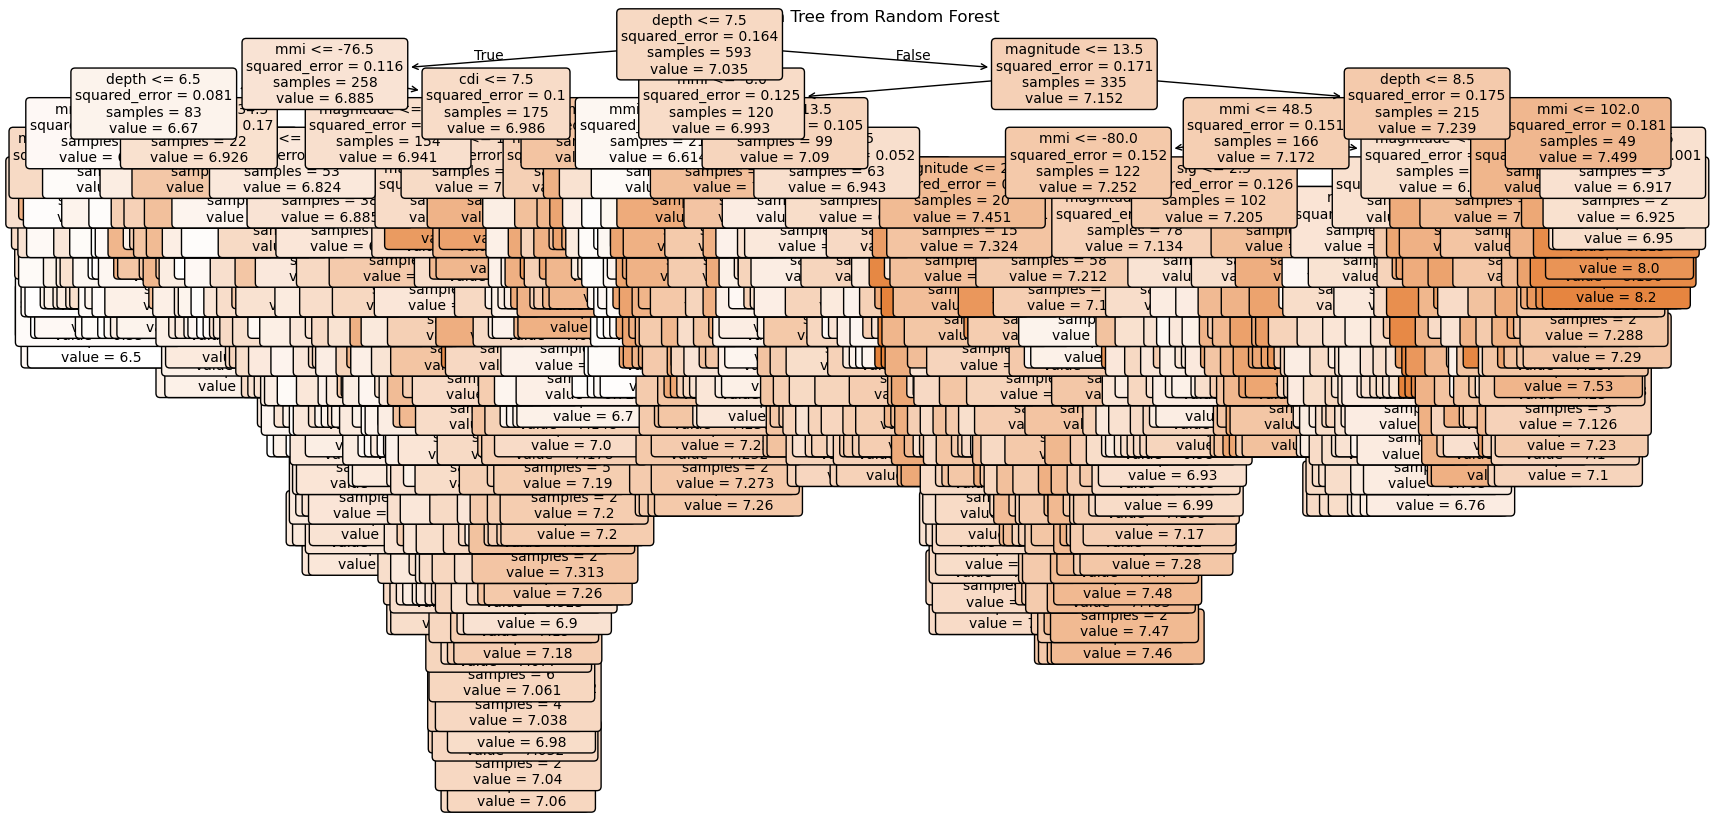

In [58]:
# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()